In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load Walmart Store Sales data
df = pd.read_csv("/content/Walmart.csv")

# Display basic information
print("Shape of dataset:", df.shape)
print("\nDataset Preview:")
display(df.head())

Shape of dataset: (6435, 8)

Dataset Preview:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
# Data types and null values
print("\nInfo:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB

Missing values per column:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Descriptive statistics:


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Extract Month, Week, Year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Year'] = df['Date'].dt.year

# Preview new features
df[['Date', 'Month', 'Week', 'Year']].head()


,Date,Month,Week,Year
0,2010-02-05,2,5,2010
1,2010-02-12,2,6,2010
2,2010-02-19,2,7,2010
3,2010-02-26,2,8,2010
4,2010-03-05,3,9,2010


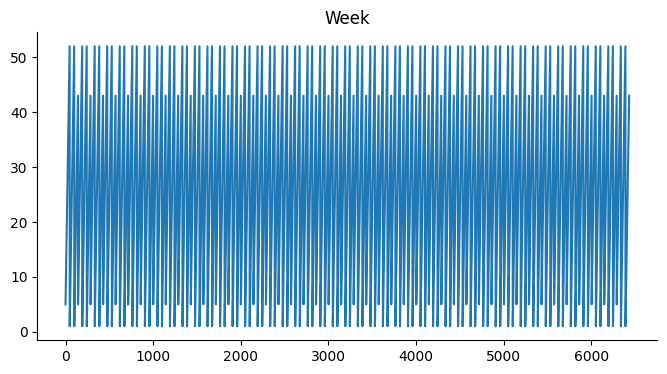

In [ ]:
from matplotlib import pyplot as plt
# Replace _df_8 with df to plot the 'Week' column from the main DataFrame
df['Week'].plot(kind='line', figsize=(8, 4), title='Week')
plt.gca().spines[['top', 'right']].set_visible(False)

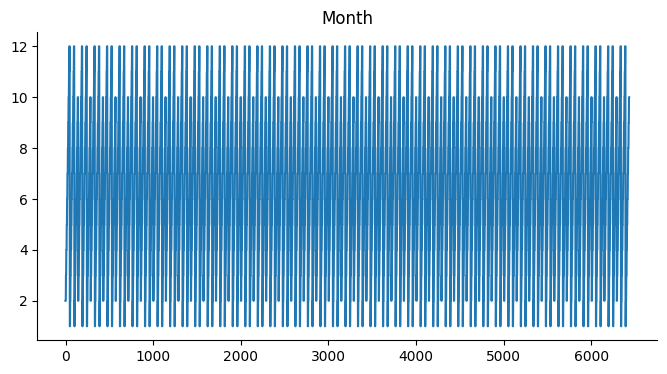

In [ ]:
from matplotlib import pyplot as plt
# Change _df_7 to df to plot from the main DataFrame
df['Month'].plot(kind='line', figsize=(8, 4), title='Month')
plt.gca().spines[['top', 'right']].set_visible(False)

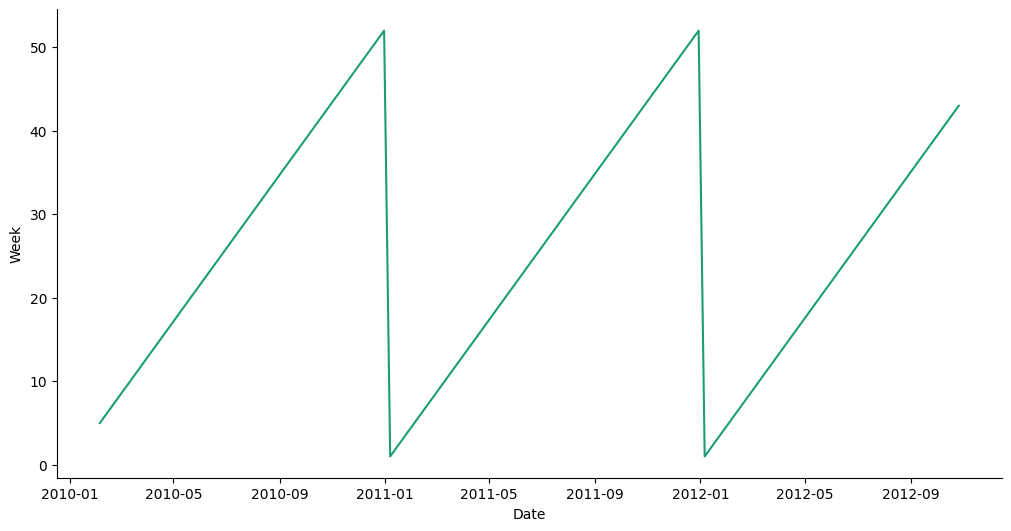

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Week']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
# Replace _df_5 with the actual DataFrame name 'df'
df_sorted = df.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Week')

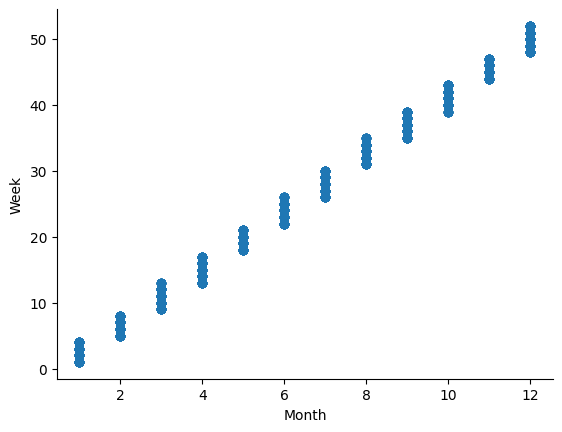

In [ ]:
from matplotlib import pyplot as plt
# Replace _df_2 with the correct DataFrame name 'df'
df.plot(kind='scatter', x='Month', y='Week', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

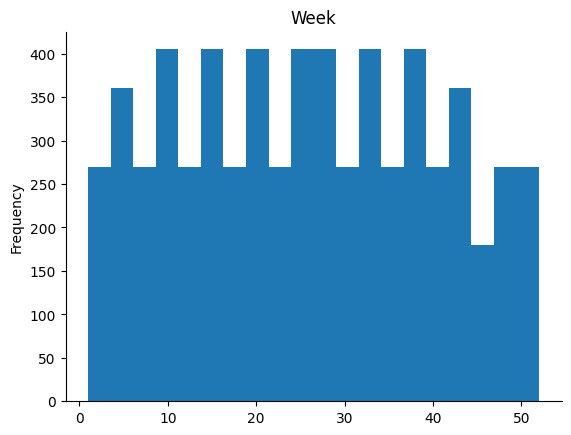

In [ ]:
from matplotlib import pyplot as plt
# Replace _df_1 with the correct DataFrame name 'df'
df['Week'].plot(kind='hist', bins=20, title='Week')
plt.gca().spines[['top', 'right',]].set_visible(False)

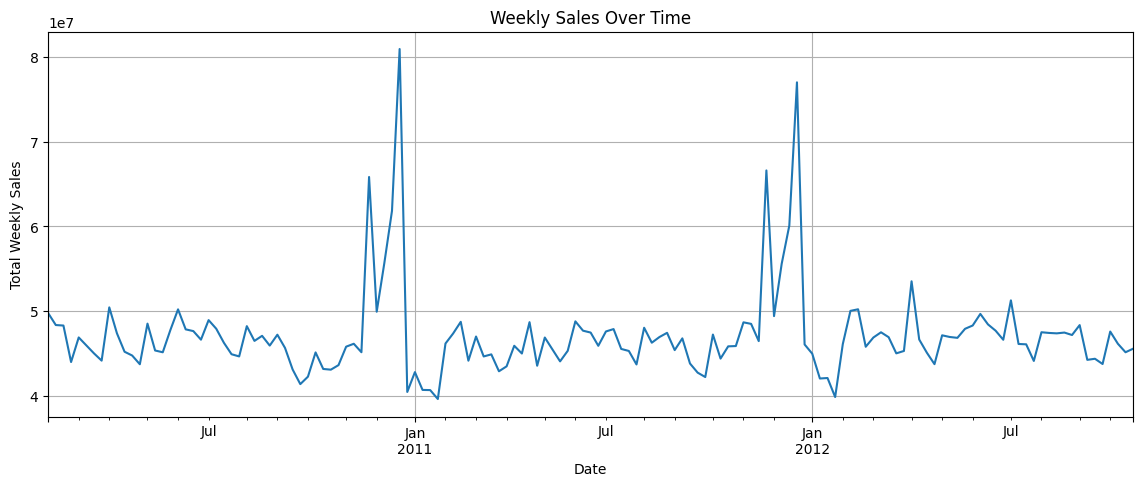

In [ ]:
plt.figure(figsize=(14, 5))
df.groupby("Date")['Weekly_Sales'].sum().plot()
plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.grid(True)
plt.show()


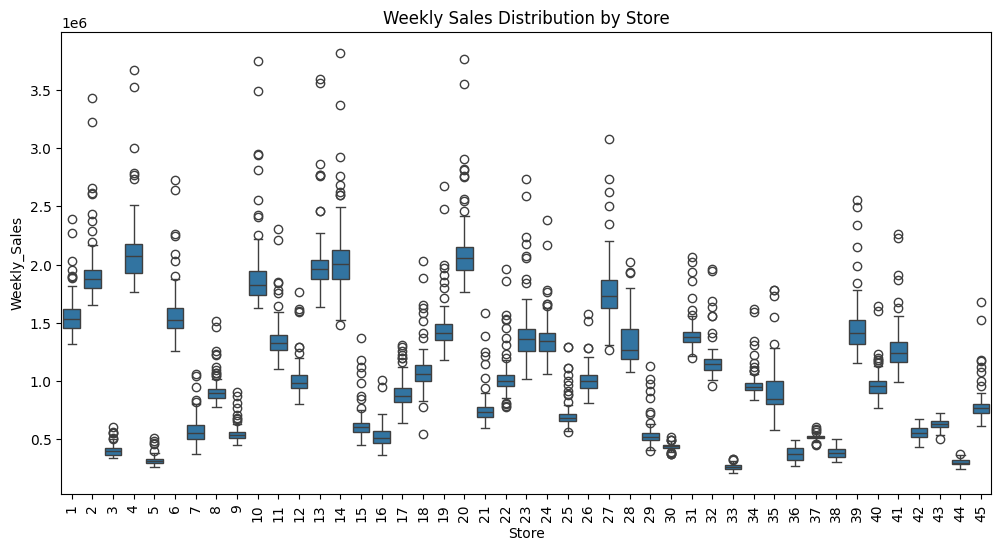

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Store', y='Weekly_Sales', data=df)
plt.title("Weekly Sales Distribution by Store")
plt.xticks(rotation=90)
plt.show()


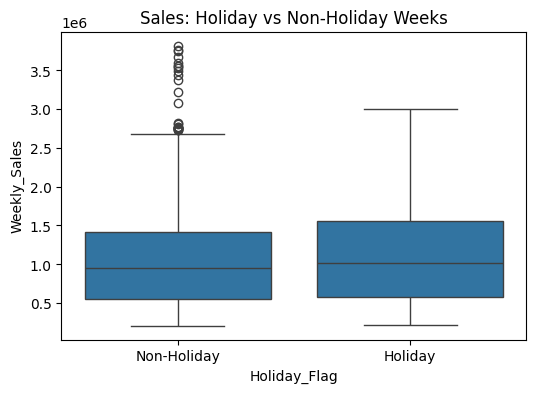

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title("Sales: Holiday vs Non-Holiday Weeks")
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.show()


In [ ]:
# Mean sales by store as a feature
store_avg_sales = df.groupby('Store')['Weekly_Sales'].transform('mean')
df['Store_Avg_Sales'] = store_avg_sales

# Lag feature: sales last week
df['Lag_1_Sales'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['Lag_1_Sales'].fillna(df['Weekly_Sales'].mean(), inplace=True)

# Drop non-numeric and unnecessary columns
df_model = df.drop(['Date'], axis=1)

# Preview final data
df_model.head()

<ipython-input-61-1813248159>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Lag_1_Sales'].fillna(df['Weekly_Sales'].mean(), inplace=True)


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Week,Year,Store_Avg_Sales,Lag_1_Sales
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2,5,2010,1.555264e+06,1.046965e+06
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2,6,2010,1.555264e+06,1.643691e+06
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2,7,2010,1.555264e+06,1.641957e+06
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2,8,2010,1.555264e+06,1.611968e+06
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,3,9,2010,1.555264e+06,1.409728e+06


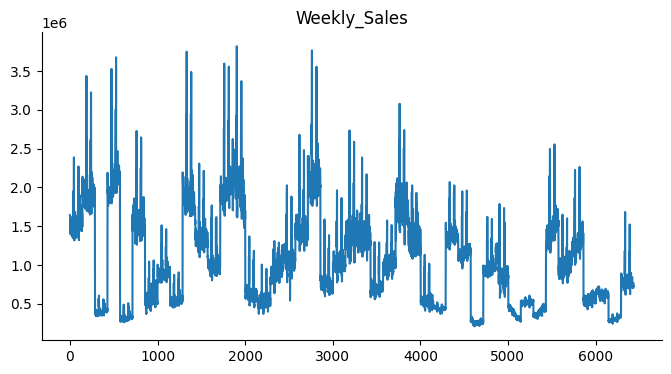

In [ ]:
from matplotlib import pyplot as plt
# Replace _df_21 with df_model to plot the 'Weekly_Sales' column
df_model['Weekly_Sales'].plot(kind='line', figsize=(8, 4), title='Weekly_Sales')
plt.gca().spines[['top', 'right']].set_visible(False)

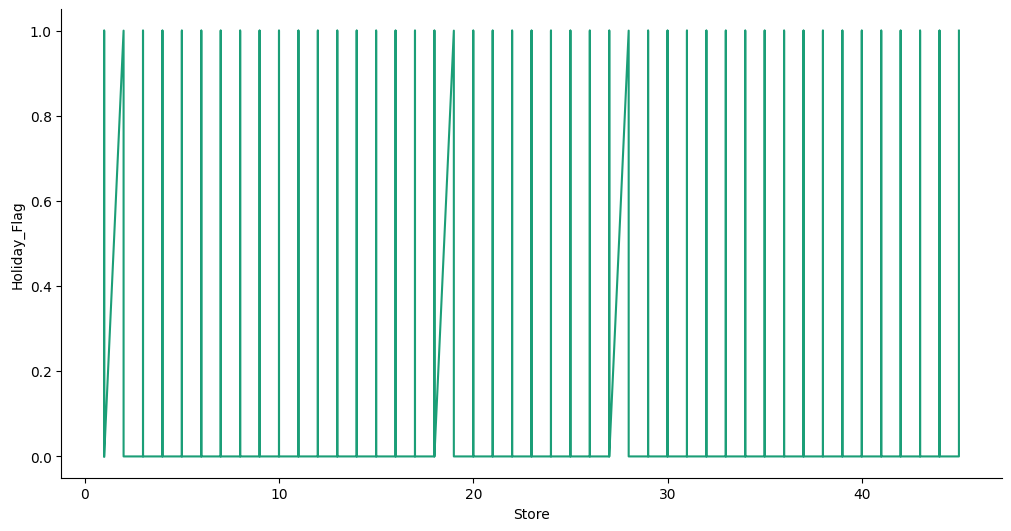

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Store']
  ys = series['Holiday_Flag']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
# Replace _df_18 with the correct DataFrame name 'df'
df_sorted = df.sort_values('Store', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Store')
_ = plt.ylabel('Holiday_Flag')

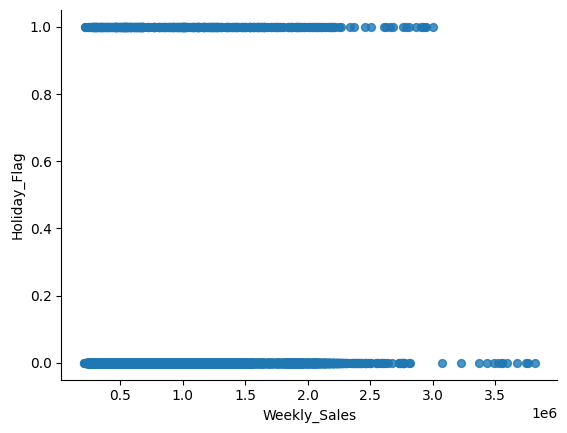

In [ ]:
from matplotlib import pyplot as plt
# Replace _df_13 with the correct DataFrame name 'df'
df.plot(kind='scatter', x='Weekly_Sales', y='Holiday_Flag', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

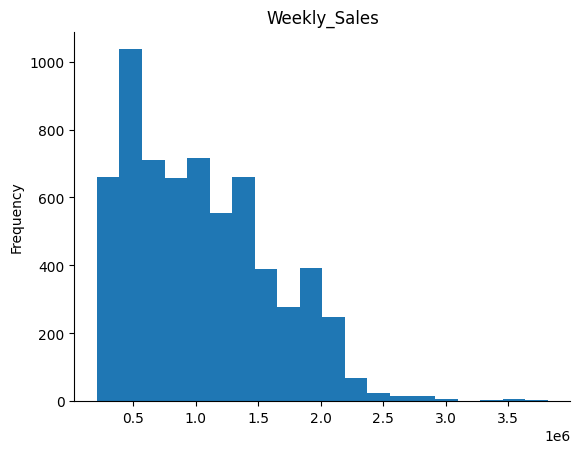

In [ ]:
from matplotlib import pyplot as plt
# Replace _df_9 with the correct DataFrame name 'df'
df['Weekly_Sales'].plot(kind='hist', bins=20, title='Weekly_Sales')
plt.gca().spines[['top', 'right',]].set_visible(False)

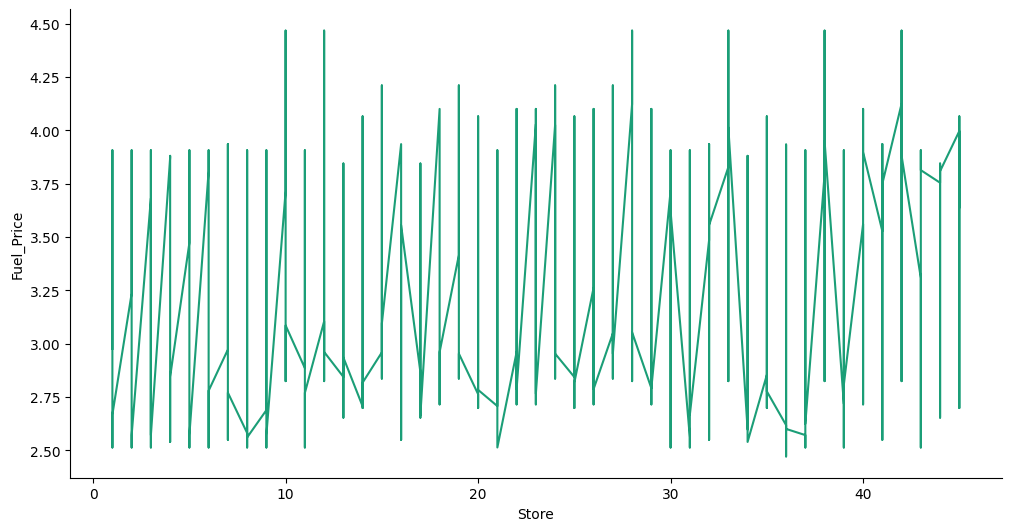

In [ ]:
# @title Store vs Fuel_Price

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Store']
  ys = series['Fuel_Price']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df_model.sort_values('Store', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Store')
_ = plt.ylabel('Fuel_Price')

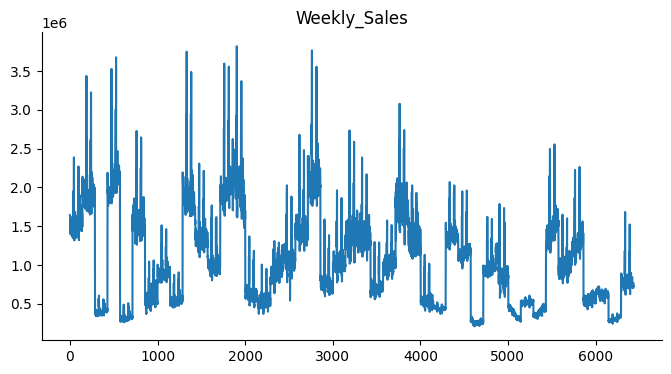

In [ ]:
# @title Weekly_Sales

from matplotlib import pyplot as plt
df_model['Weekly_Sales'].plot(kind='line', figsize=(8, 4), title='Weekly_Sales')
plt.gca().spines[['top', 'right']].set_visible(False)

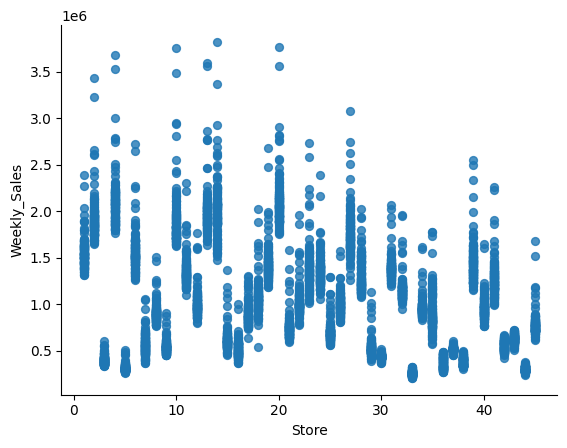

In [ ]:
# @title Store vs Weekly_Sales

from matplotlib import pyplot as plt
df_model.plot(kind='scatter', x='Store', y='Weekly_Sales', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# Define input features and target
X = df_model.drop('Weekly_Sales', axis=1)
y = df_model['Weekly_Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5148
Testing samples: 1287


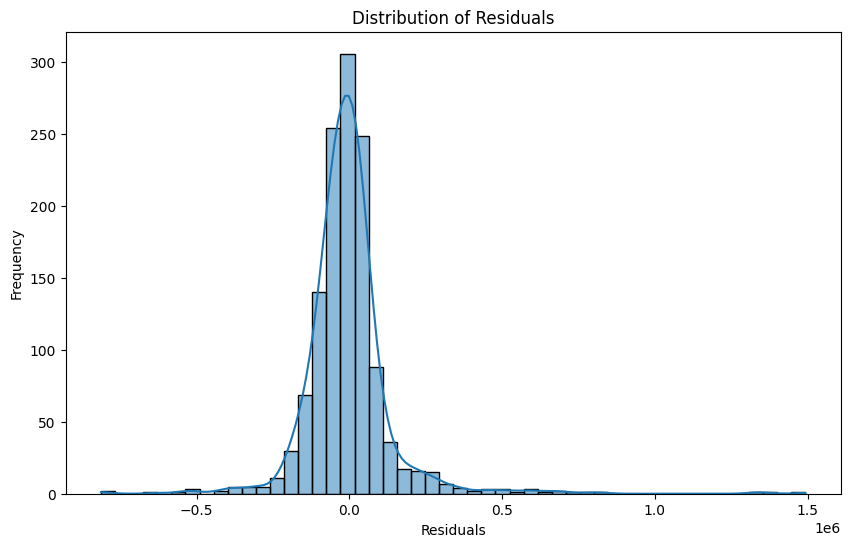

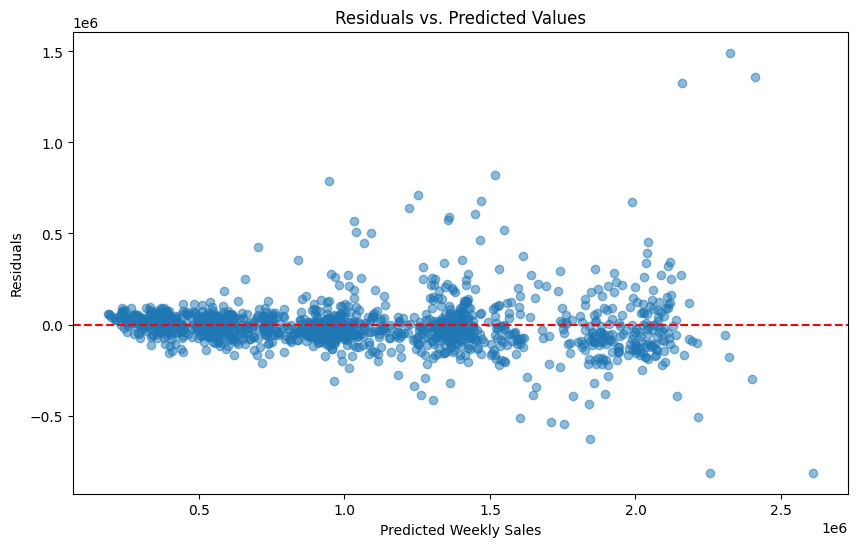


Data points with large residuals (potential outliers):


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Week,Year,Store_Avg_Sales,Lag_1_Sales
1867,14,2010-04-02,2495630.51,0,47.74,2.850,181.865754,8.899,4,13,2010,2.020978e+06,2050396.27
3240,23,2011-11-25,2057059.53,1,35.23,3.536,136.478800,4.420,11,47,2011,1.389864e+06,1345631.96
3765,27,2010-12-31,1440963.00,1,29.59,3.336,136.665265,8.021,12,52,2010,1.775216e+06,3078162.08
4956,35,2011-11-25,1733822.40,1,47.88,3.492,140.421786,8.745,11,47,2011,9.197250e+05,820964.10
1047,8,2010-12-24,1511641.09,0,45.67,2.886,214.747907,6.433,12,51,2010,9.087495e+05,1220579.55
3908,28,2010-12-31,1090558.57,1,45.64,3.148,127.087677,14.313,12,52,2010,1.323522e+06,2026026.39
1477,11,2010-12-31,1172003.10,1,55.03,2.943,214.698647,7.564,12,52,2010,1.356383e+06,2306265.36
4479,32,2010-12-24,1949183.14,0,30.72,2.781,191.143019,9.137,12,51,2010,1.166568e+06,1557776.10
4960,35,2011-12-23,1550214.02,0,41.59,3.389,140.528765,8.745,12,51,2011,9.197250e+05,1115255.65
5528,39,2011-11-25,2338832.40,1,66.36,3.236,217.181253,7.716,11,47,2011,1.450668e+06,1510397.27



Analysis of Outlier Residuals:


,y_test,y_pred,residuals
1905,3818686.45,2.325903e+06,1.492783e+06
2763,3766687.43,2.409119e+06,1.357568e+06
1385,3487986.89,2.160493e+06,1.327493e+06
5528,2338832.40,1.515667e+06,8.231656e+05
4956,1733822.40,9.472257e+05,7.865967e+05
3049,1962445.04,1.252989e+06,7.094560e+05
5476,2149355.20,1.469015e+06,6.803401e+05
185,2658725.29,1.987232e+06,6.714932e+05
3101,1863195.68,1.223029e+06,6.401663e+05
3240,2057059.53,1.447466e+06,6.095936e+05



Full data for outlier weeks:


...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Temperature']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = outlier_data.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Temperature')

from matplotlib import pyplot as plt
outlier_data['Store'].plot(kind='line', figsize=(8, 4), title='Store')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
outlier_data['Weekly_Sales'].plot(kind='line', figsize=(8, 4), title='Weekly_Sales')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
outlier_data['Holiday_Flag'].plot(kind='line', figsize=(8, 4), title='Holiday_Flag')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
outlier_data['Temperature'].plot(kind='line', figsize=(8, 4), title='Temperature')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression # Import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# A. Residual Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Scatter plot of residuals vs. predicted values to check for homoscedasticity and patterns
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Weekly Sales')
plt.ylabel('Residuals')
plt.show()

# B. Outliers - Identify points with large residuals
# Let's define a threshold for large residuals (e.g., 3 standard deviations)
residual_std = residuals.std()
outlier_threshold = 3 * residual_std

outlier_indices = residuals[(residuals > outlier_threshold) | (residuals < -outlier_threshold)].index
outlier_data = df.loc[outlier_indices] # Use the original df to see date and other features

print("\nData points with large residuals (potential outliers):")
display(outlier_data)

# You can further analyze these outlier data points in relation to the original data
# For example, joining with the original dataframe that still has the 'Date' column
outlier_analysis_df = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred, 'residuals': residuals})
outlier_analysis_df = outlier_analysis_df.loc[outlier_indices].sort_values(by='residuals', ascending=False)

print("\nAnalysis of Outlier Residuals:")
display(outlier_analysis_df)

# To relate outliers to the original data (including Date), merge with the original test set indices
outlier_full_data = df.loc[outlier_analysis_df.index]
print("\nFull data for outlier weeks:")
# Corrected the column list: changed 'IsHoliday' to 'Holiday_Flag' and removed the duplicate 'Weekly_Sales'
display(outlier_full_data[['Date', 'Store', 'Weekly_Sales', 'Holiday_Flag'] + [col for col in df.columns if col in X_test.columns]])

# You can now visually inspect the dates and features for these outlier weeks to identify potential causes
# based on the business understanding of the data.


In [ ]:
# Train linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


Linear Regression R2 Score: 0.9340720140834151
Linear Regression RMSE: 145736.06828831465


In [ ]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


Random Forest R2 Score: 0.9789321111677693
Random Forest RMSE: 82383.9581138171


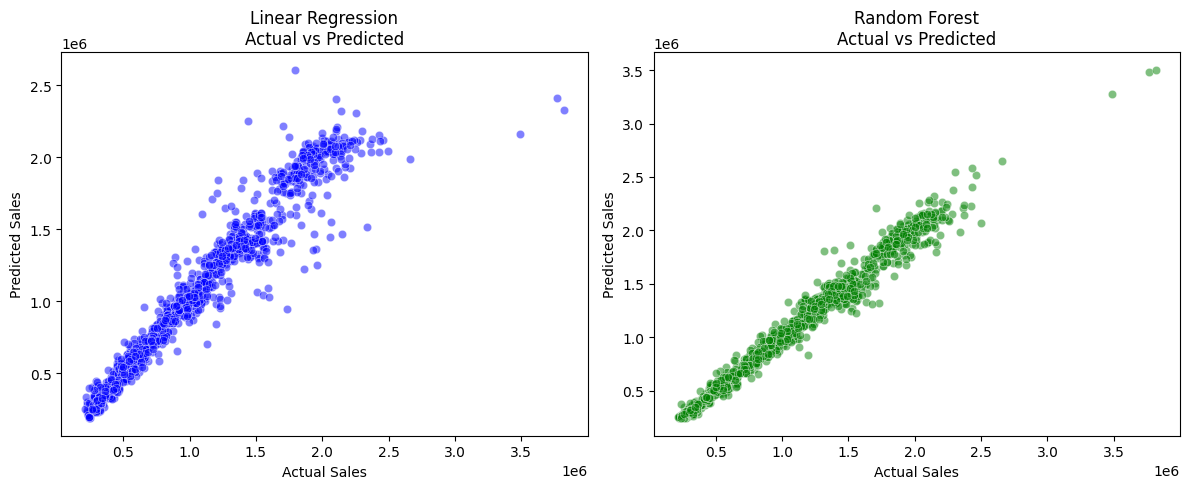

In [ ]:
plt.figure(figsize=(12, 5))

# Actual vs Linear Regression
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, color='blue', alpha=0.5)
plt.title("Linear Regression\nActual vs Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

# Actual vs Random Forest
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_rf, color='green', alpha=0.5)
plt.title("Random Forest\nActual vs Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.show()


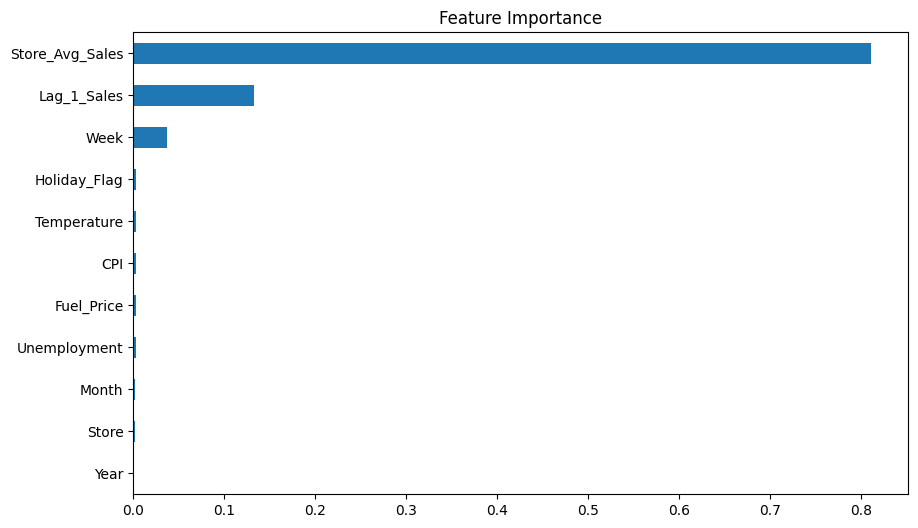

In [ ]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', figsize=(10, 6), title='Feature Importance')
plt.show()


- We successfully performed sales prediction using two models: Linear Regression and Random Forest.
- Random Forest outperformed Linear Regression with a higher R² and lower RMSE.
- Features like `Lag_1_Sales`, `Store_Avg_Sales`, `Holiday_Flag`, and `Month` were important predictors.
- The model can help stores in forecasting demand, optimizing inventory, and planning for holiday sales boosts.
